<a href="https://colab.research.google.com/github/Maryam-Taherzadeh/Computational-Drug-Discovery/blob/main/project-01-predict-ic50-mdm2-p53/notebooks/mdm2_part5_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###  Part 5: Comparing Regression Models (MDM2 Inhibitors)

**Author: Maryam Taherzadeh**

In this section, multiple machine learning regression models are evaluated to predict the bioactivity (**pIC50**) of small molecules targeting the **MDM2–p53 interaction**, a key protein–protein interaction in cancer biology.

This step extends the computational drug discovery pipeline by comparing different algorithms to identify the most effective approach for modeling the structure–activity relationship (SAR).

---

###  Objective

- Train and evaluate multiple regression models  
- Compare performance across models using consistent metrics  
- Identify candidate models for further optimization  

---

###  Models Compared

A broad set of regression models is evaluated using automated benchmarking to identify high-performing algorithms.

---

###  Input Data

- **X (features):**
  - PaDEL molecular descriptors  
  - PubChem fingerprint vectors  

- **y (target):**
  - Experimental **pIC50 values**

---

###  Workflow

1. Load preprocessed dataset from previous steps  
2. Split data into training and testing sets  
3. Apply automated benchmarking (e.g., LazyPredict)  
4. Generate predictions on the test dataset  
5. Evaluate and compare performance  

---

###  Evaluation Metrics

- **R² (Coefficient of Determination)**  
  Measures the proportion of variance in pIC50 explained by the model  

- **MSE (Mean Squared Error)**  
  Penalizes larger prediction errors  

- **MAE (Mean Absolute Error)**  
  Represents average prediction error in pIC50 units  

---

###  Automated Benchmarking Insights

Using LazyPredict, a wide range of machine learning algorithms were benchmarked under default settings.

The results show that ensemble and gradient boosting methods, including:
- HistGradientBoostingRegressor  
- XGBoost Regressor  
- Random Forest Regressor  

consistently achieved higher R² scores compared to linear and simpler models.

---

###  Significance

Model comparison is a critical step in QSAR modeling, as it helps identify algorithms that can effectively capture complex, nonlinear relationships between molecular structure and biological activity.

The results indicate that the structure–activity relationship is **inherently nonlinear**, requiring more advanced modeling approaches.

---

###  Conclusion

In this section, baseline regression models were evaluated to predict the bioactivity (pIC50) of MDM2 inhibitors using molecular descriptors and fingerprint features.

The results show that while Random Forest provides a solid baseline performance, more advanced ensemble and boosting methods demonstrate stronger predictive potential.

Based on automated benchmarking results, **gradient boosting models — particularly XGBoost — emerge as strong candidates for further development**.

---

###  Next Steps

- Develop a dedicated **XGBoost regression model** in the next notebook (Part 6)  
- Perform hyperparameter tuning to improve model performance  
- Compare tuned XGBoost with baseline models  
- Explore advanced molecular representations (e.g., Graph Neural Networks)  
- Integrate structural features (e.g., docking-based descriptors)  
- Deploy the final model for real-time prediction (e.g., Streamlit application)  

## **1. Import libraries**

In [1]:
! pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 5.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyRegressor

## **2. Load the data set**


In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/mdm2_07_padel_descriptors_pIC50.csv')
df.shape

Mounted at /content/drive


(5792, 882)

In [4]:
X = df.drop('pIC50', axis=1)
y = df.pIC50


## **3. Data pre-processing**

In [5]:
# Examine X dimension
X.shape

(5792, 881)

In [6]:
# Remove low variance features
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)
X.shape

(5792, 192)

In [7]:
# Perform data splitting using 80/20 ratio

from sklearn.model_selection import train_test_split

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **4. Compare ML algorithms**

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
HistGradientBoostingRegressor,0.580,0.649,0.843,1.464
NuSVR,0.562,0.635,0.861,2.608
XGBRegressor,0.561,0.634,0.861,0.792
SVR,0.561,0.634,0.862,4.884
LGBMRegressor,0.554,0.628,0.868,0.478
RandomForestRegressor,0.553,0.627,0.870,5.858
MLPRegressor,0.540,0.616,0.882,6.966
KNeighborsRegressor,0.539,0.616,0.883,0.177
GradientBoostingRegressor,0.535,0.612,0.887,2.671


/tmp/ipykernel_3240/3362932267.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


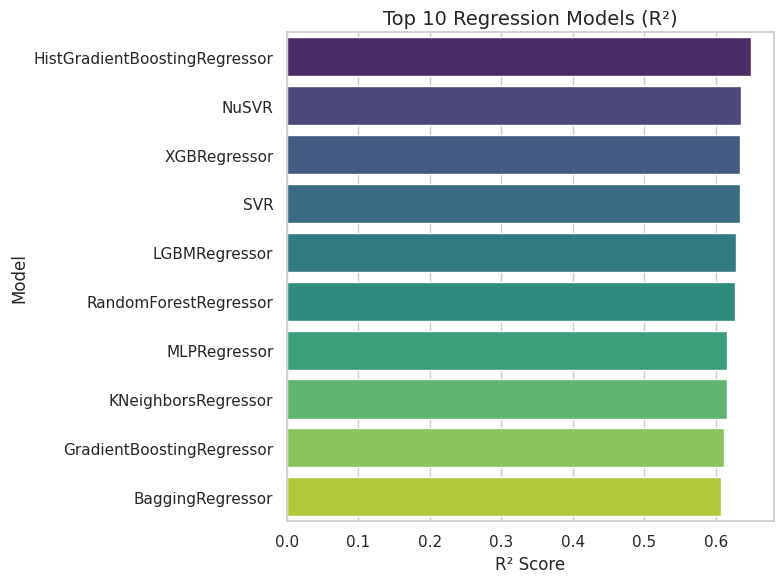

In [8]:
from lazypredict.Supervised import LazyRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Run LazyPredict
clf = LazyRegressor(verbose=0, ignore_warnings=True)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Sort and clean
models_sorted = models.sort_values(by='R-Squared', ascending=False).round(3)

# Top 10 models
top_models = models_sorted.head(10)

# Display table
display(top_models)

# Plot
plt.figure(figsize=(8,6))
sns.set_theme(style="whitegrid")

sns.barplot(
    y=top_models.index,
    x=top_models["R-Squared"],
    palette="viridis"
)

plt.title("Top 10 Regression Models (R²)", fontsize=14)
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [9]:
# Performance table of the test set
models_sorted = models.sort_values(by='R-Squared', ascending=False).round(3)
display(models_sorted.head(10))

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
HistGradientBoostingRegressor,0.580,0.649,0.843,1.464
NuSVR,0.562,0.635,0.861,2.608
XGBRegressor,0.561,0.634,0.861,0.792
SVR,0.561,0.634,0.862,4.884
LGBMRegressor,0.554,0.628,0.868,0.478
RandomForestRegressor,0.553,0.627,0.870,5.858
MLPRegressor,0.540,0.616,0.882,6.966
KNeighborsRegressor,0.539,0.616,0.883,0.177
GradientBoostingRegressor,0.535,0.612,0.887,2.671


## **5. Data visualization of model performance**

/tmp/ipykernel_3240/1089827075.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


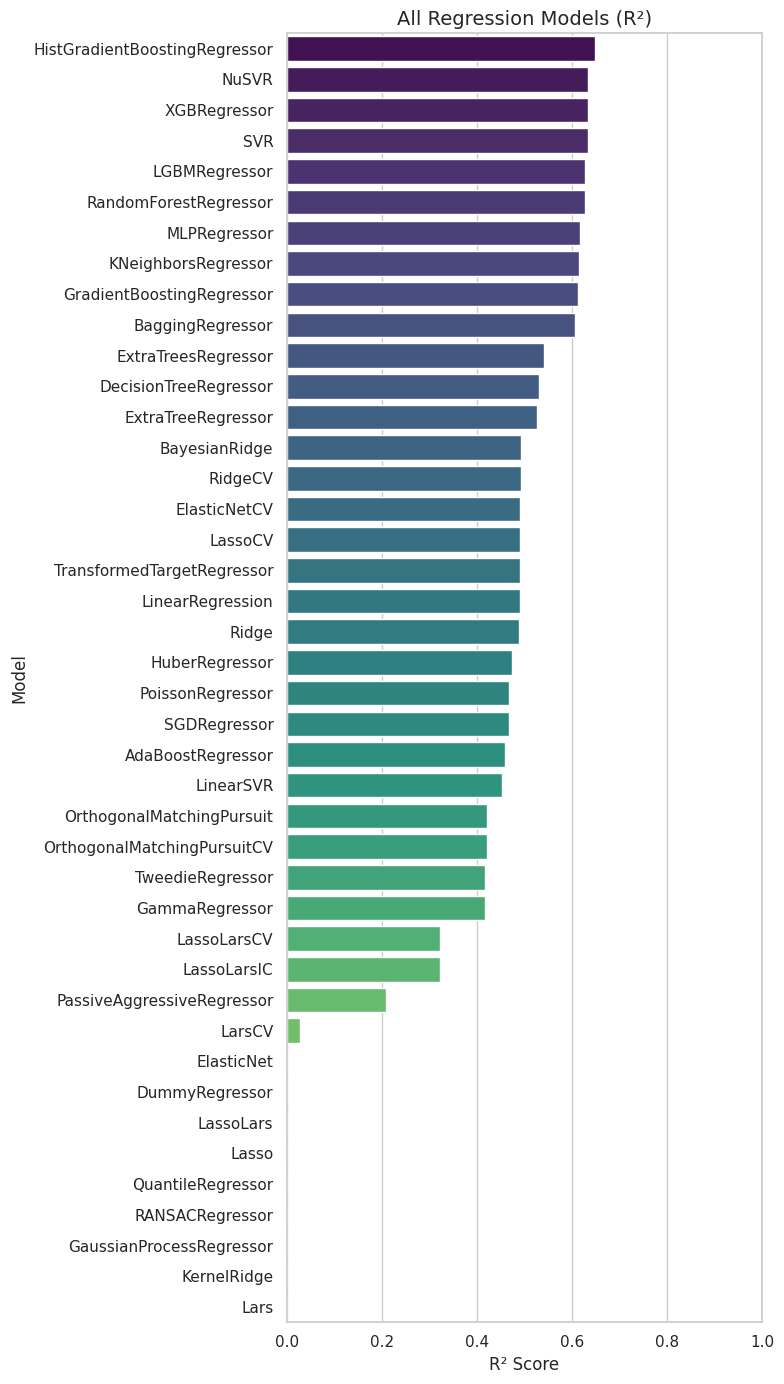

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort models
models_sorted = models.sort_values(by='R-Squared', ascending=False)

plt.figure(figsize=(8,14))
sns.set_theme(style="whitegrid")

# Colorful palette
sns.barplot(
    y=models_sorted.index,
    x=models_sorted["R-Squared"],
    palette="viridis"
)

plt.xlim(0, 1)
plt.title("All Regression Models (R²)", fontsize=14)
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3240/3666869530.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


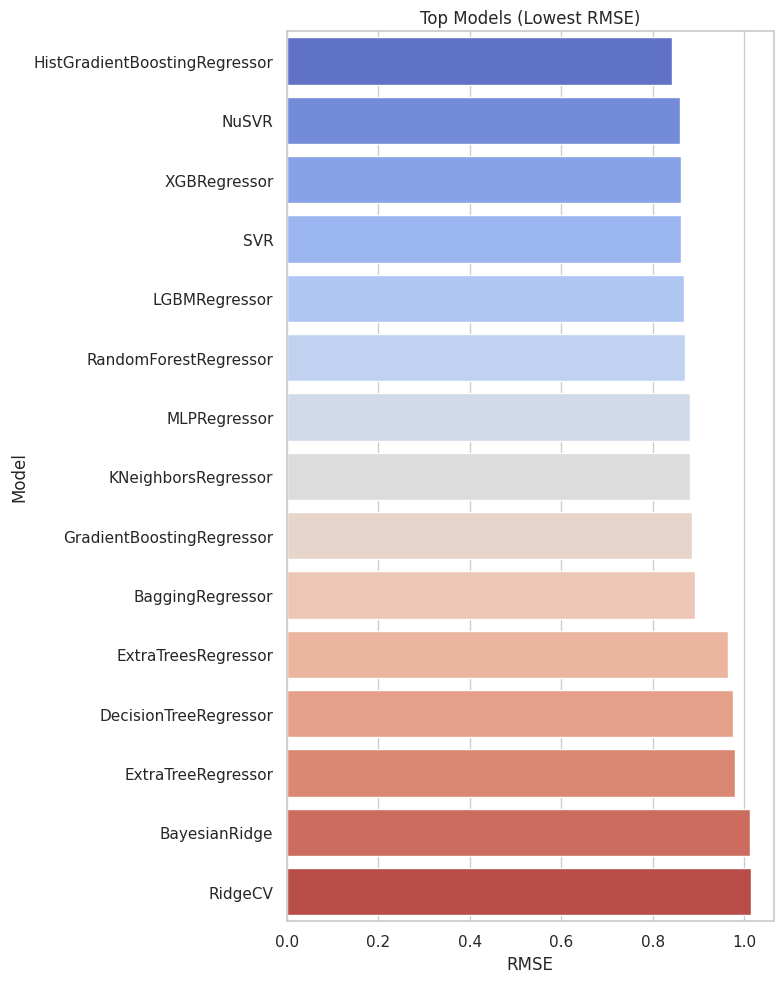

In [11]:
models_rmse = models.sort_values(by='RMSE', ascending=True)

top_models = models_rmse.head(15)  # keep only good models

plt.figure(figsize=(8,10))
sns.set_theme(style="whitegrid")

sns.barplot(
    y=top_models.index,
    x=top_models["RMSE"],
    palette="coolwarm"
)

plt.title("Top Models (Lowest RMSE)")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3240/126411503.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


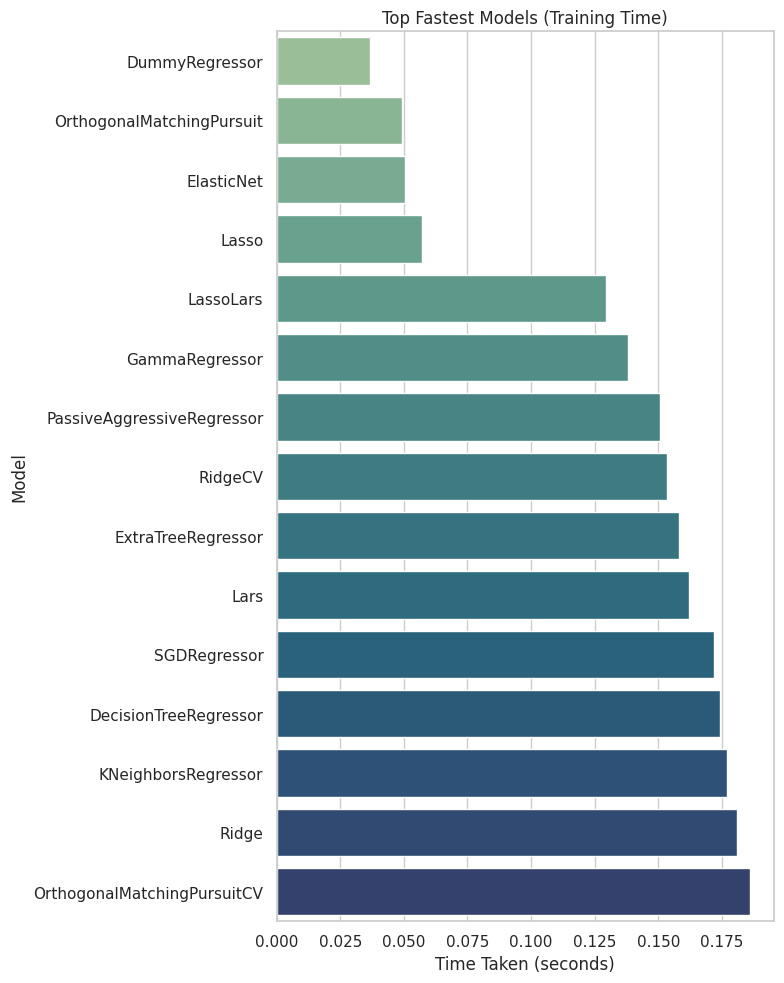

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by time (fastest first)
models_time = models.sort_values(by='Time Taken', ascending=True)

# Show top 15 fastest models
top_time = models_time.head(15)

plt.figure(figsize=(8,10))
sns.set_theme(style="whitegrid")

sns.barplot(
    y=top_time.index,
    x=top_time["Time Taken"],
    palette="crest"
)

plt.title("Top Fastest Models (Training Time)")
plt.xlabel("Time Taken (seconds)")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

### 📌 Conclusion

In this section, multiple regression models were evaluated to predict the bioactivity (**pIC50**) of MDM2 inhibitors using molecular descriptors and fingerprint features.

Using LazyPredict, a wide range of machine learning algorithms were benchmarked under default settings. The results show that ensemble and gradient boosting methods—such as HistGradientBoosting, XGBoost, and Random Forest—consistently achieve higher R² scores compared to linear and simpler models.

These findings indicate that the relationship between molecular structure and biological activity is **highly nonlinear**, requiring more advanced models to capture these complex patterns.

It is important to note that these results are based on **default hyperparameters**, and therefore serve as an initial benchmarking step rather than a final evaluation. Model performance can be further improved through systematic hyperparameter tuning.

Based on overall performance, robustness, and scalability, **XGBoost is selected as the most promising model for further optimization**.

In the next step, a dedicated XGBoost model will be developed and fine-tuned to improve predictive accuracy and build a more reliable QSAR model for pIC50 prediction.